In [ ]:
!pip install torchviz


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **This IPYNB Notebook was run locally on my system which has an RTX 4070 Super GPU 12 GB Vram**

# **Data Loading**

In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import string
import math
import time
from bs4 import BeautifulSoup
from collections import Counter, defaultdict
import networkx as nx
from scipy.spatial.distance import pdist, squareform

# Sklearn libraries for machine learning and text processing
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, cross_validate, validation_curve, learning_curve
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.utils import shuffle
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances


# NLTK libraries for text processing (lemmatization, stemming, stopwords, POS tagging)
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk import ne_chunk, pos_tag
from nltk.tree import Tree


# Download necessary NLTK resources for text processing
nltk.download('wordnet')  # WordNet for lemmatization
nltk.download('omw-1.4')  # Open Multilingual Wordnet
nltk.download('punkt')  # Tokenizer
nltk.download('punkt_tab')
nltk.download('stopwords')  # Stopwords for text cleaning
nltk.download('averaged_perceptron_tagger')  # POS tagger for part-of-speech tagging
nltk.download('averaged_perceptron_tagger_eng')  # Additional tagger
nltk.download('tagsets_json')  # Tagset resource

print("\n All libraries imported successfully!")


# Deep Learning Libraries
from keras.layers import Dropout, Dense, GRU, Embedding, LSTM, Bidirectional, TimeDistributed, Flatten
from keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,Conv1D,Flatten,Embedding,MaxPool1D,concatenate,Dropout
from tensorflow.keras.callbacks import ModelCheckpoint,TensorBoard,EarlyStopping
from tensorflow.keras.optimizers import Adam

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from tqdm import tqdm


# Logging
import logging
logging.basicConfig(level=logging.INFO)



# Data Visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")
# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as pyo
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sonja\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sonja\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sonja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sonja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sonja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sonja\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nl


 All libraries imported successfully!


In [ ]:
use_cuda = torch.cuda.is_available()

# Use this line below to enforce the use of the CPU (in case you don't have a supported GPU)
# With this small dataset and simple model you won't see a difference anyway
# use_cuda = False  # Uncomment this line to force CPU usage

device = torch.device("cuda:0" if use_cuda else "cpu")

print("Available device: {}".format(device))
print("If you see 'cuda:0', it means GPU is available and will be used")
print("If you see 'cpu', it means only CPU will be used")

Available device: cuda:0
If you see 'cuda:0', it means GPU is available and will be used
If you see 'cpu', it means only CPU will be used


In [ ]:

df_train = pd.read_excel('data\AI_vs_huam_train_dataset.xlsx')
df_test = pd.read_csv('data\Final_test_data.csv')

In [ ]:
df_train

,essay,label
0,International sports events require the most w...,0
1,Globalisation has become a significant aspect ...,0
2,There is an ever-increasing number of bullying...,0
3,"It is commonly believed, that companies should...",0
4,Despite knowing about the adverse effects of c...,0
...,...,...
3723,I agree that successful people are willing to ...,1
3724,I believe that people who are open to trying n...,1
3725,"To succeed in life, we must do everything poss...",1
3726,"I'm not entirely sure what the word ""successfu...",1


In [ ]:
print("Dataset Information:")
print(f"Training data shape: {df_train.shape}")
print(f"Test data shape: {df_test.shape}")
print(f"Columns: {df_train.columns.tolist()}")

# Show first few rows
print("\nFirst 5 rows of training data:")
print(df_train.head())

# Check label distribution
print("\nLabel distribution:")
print(df_train['label'].value_counts())

Dataset Information:
Training data shape: (3728, 2)
Test data shape: (869, 2)
Columns: ['essay', 'label']

First 5 rows of training data:
                                               essay  label
0  International sports events require the most w...      0
1  Globalisation has become a significant aspect ...      0
2  There is an ever-increasing number of bullying...      0
3  It is commonly believed, that companies should...      0
4  Despite knowing about the adverse effects of c...      0

Label distribution:
label
0    1864
1    1864
Name: count, dtype: int64


# **Text PreProcessing Using lemmatization**

In [ ]:
#  Advanced Text Preprocessing with Lemmatization

class TextPreprocessor:
    """
    Advanced text preprocessing class with lemmatization
    This will clean text better than basic preprocessing
    """

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        # Add custom stop words
        self.stop_words.update(['u', 'ur', '4', '2', 'im', 'dont', 'doin', 'ure'])

    def get_wordnet_pos(self, word):
        """Convert POS tag to format accepted by WordNet lemmatizer"""
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}
        return tag_dict.get(tag, wordnet.NOUN)

    def clean_text(self, text):
        """Basic text cleaning"""
        if not isinstance(text, str):
            return ""

        # Convert to lowercase
        text = text.lower()

        # Remove URLs, emails, HTML tags
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'\S+@\S+', '', text)
        text = re.sub(r'<.*?>', '', text)

        # Remove special characters but keep spaces
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remove extra whitespace
        text = ' '.join(text.split())

        return text

    def lemmatize_text(self, text):
        """Apply lemmatization with POS tagging"""
        tokens = word_tokenize(text)

        lemmatized_tokens = []
        for token in tokens:
            if token not in self.stop_words and len(token) > 2:
                # Get POS tag and lemmatize
                pos_tag = self.get_wordnet_pos(token)
                lemmatized_token = self.lemmatizer.lemmatize(token, pos_tag)
                lemmatized_tokens.append(lemmatized_token)

        return ' '.join(lemmatized_tokens)

    def preprocess(self, text):
        """Complete preprocessing pipeline"""
        cleaned_text = self.clean_text(text)
        lemmatized_text = self.lemmatize_text(cleaned_text)
        return lemmatized_text

print("Text preprocessing class created!")

Text preprocessing class created!


In [ ]:
# Apply Text Preprocessing to the "essay" column

# Initialize the preprocessor
preprocessor = TextPreprocessor()

print("Applying advanced text preprocessing with lemmatization...")

# Apply preprocessing to training data
df_train['clean_text'] = df_train['essay'].apply(preprocessor.preprocess)

# Apply preprocessing to test data
df_test['clean_text'] = df_test['essay'].apply(preprocessor.preprocess)

print("Text preprocessing completed!")

Applying advanced text preprocessing with lemmatization...
Text preprocessing completed!


In [ ]:
# Show examples of preprocessing
print("\nExamples of text preprocessing:")
print("Original:", df_train['essay'].iloc[0])
print("Processed:", df_train['clean_text'].iloc[0])
print()
print("Original:", df_train['essay'].iloc[5])
print("Processed:", df_train['clean_text'].iloc[5])


Examples of text preprocessing:
Original: International sports events require the most well-trained athletes for each country, in order to achieve this goal countries make an effort to build infrastructure designed to train top athletes. Although this policy can indeed make fewer sports facilities for ordinary people, investing in the best athletes is vital to develop competitive sports performances in each country.
On the one hand, building specific infrastructure for the best athletes is crucial in order to get better results at international sports events such as The Olympics or the World Cup. The importance of getting better results is that it creates awareness of the importance of sports in society and motivates more people to do a sport. In this way, investing in these developments can help countries to develop an integral sport policy that can benefit everyone.
On the other hand, one can argue that a negative effect could be that less infrastructure is built for the rest of the

In [ ]:
# The labels are already binary (0 and 1) in the 'label' column of df_train
# No need to filter or map sentiments for binary classification

print(f"Original training data: {len(df_train)} samples")

# Check label distribution in the original training data
print("\nLabel distribution in original training data:")
print(df_train['label'].value_counts())

print("\nProceeding with binary classification using the 'label' column.")

Original training data: 3728 samples

Label distribution in original training data:
label
0    1864
1    1864
Name: count, dtype: int64

Proceeding with binary classification using the 'label' column.


In [ ]:
# Define features and target using the full training data
X = df_train['clean_text']  # All text data
y = df_train['label']       # All labels

print(f"Total input text samples: {len(X)}")
print(f"Total labels: {len(y)}")

# Count labels
label_counts = np.bincount(y)
print(f"Label distribution: {label_counts}")
print(f"Number of 0s (class 0): {label_counts[0]:,}")
print(f"Number of 1s (class 1): {label_counts[1]:,}")


# Calculate percentages
total_samples = len(y)
percentage_0 = (label_counts[0] / total_samples) * 100
percentage_1 = (label_counts[1] / total_samples) * 100

print(f"Percentage of 0s: {percentage_0:.1f}%")
print(f"Percentage of 1s: {percentage_1:.1f}%")

print(f"\nFirst sample: {X.iloc[0][:100]}...")

Total input text samples: 3728
Total labels: 3728
Label distribution: [1864 1864]
Number of 0s (class 0): 1,864
Number of 1s (class 1): 1,864
Percentage of 0s: 50.0%
Percentage of 1s: 50.0%

First sample: international sport event require welltrained athlete country order achieve goal country make effort...


# **Word Embeddings using GLOVE**

In [ ]:
print("Applying train-test split on pre-processed text data...")

X_train, X_val, y_train, y_val = train_test_split(
    X,                    # preprocessed text data
    y,                    # Labels
    test_size=0.2,        # 20% for validation
    random_state=42,      # For reproducibility
    stratify=y            # Maintain label distribution
)

print(f"Train-test split completed:")
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")

Applying train-test split on pre-processed text data...
Train-test split completed:
Training samples: 2,982
Validation samples: 746


In [ ]:
# Set random seed for reproducible results
np.random.seed(7)


#Tokenization (Fit ONLY on training data)
print("\n" + "="*60)
print("TOKENIZATION")
print("="*60)

print("Fitting tokenizer on training data only...")

# Initialize tokenizer
tokenizer = Tokenizer(filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')

# Fit tokenizer ONLY on training data
tokenizer.fit_on_texts(X_train)

print(f"\nTokenizer vocabulary size: {len(tokenizer.word_index):,}")

# Get word index (word to integer mapping)
word_index = tokenizer.word_index

print(f"Found {len(word_index)} unique tokens")

# Show most common words
print(f"\nMost frequent words:")
for i, (word, index) in enumerate(list(word_index.items())[:10]):
    print(f"  {i+1}. '{word}': index {index}")


TOKENIZATION
Fitting tokenizer on training data only...

Tokenizer vocabulary size: 18,742
Found 18742 unique tokens

Most frequent words:
  1. 'people': index 1
  2. 'new': index 2
  3. 'risk': index 3
  4. 'take': index 4
  5. 'thing': index 5
  6. 'try': index 6
  7. 'successful': index 7
  8. 'life': index 8
  9. 'success': index 9
  10. 'well': index 10


In [ ]:
# Convert texts to sequences
print("Converting texts to sequences...")
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

print("Text to sequence conversion completed.")

Converting texts to sequences...
Text to sequence conversion completed.


In [ ]:
for i in range(4):
    print(X_train_seq[i])

[1071, 1072, 26, 383, 1029, 14, 1, 161, 11, 1829, 1433, 195, 54, 60, 82, 435, 1175, 125, 47, 100, 689, 850, 61, 39, 218, 1058, 5, 100, 1515, 5083, 3056, 47, 57, 2095, 141, 1626, 189, 16, 23, 709, 274, 5, 12, 1830, 435, 283, 1049, 9, 13, 54, 811, 302, 1515, 942, 1831, 172, 1515, 147, 262, 246, 306, 435, 4451, 1369, 1058, 134, 60, 157, 124, 26, 746, 13, 1515, 6016, 53, 121, 172, 309, 767, 487, 302, 1515, 6017, 279, 1175, 5084, 1410, 31, 1696, 66, 16, 195, 1696, 8278, 145, 479, 61, 1230, 27, 8279, 237, 54, 3219, 90, 23, 435, 1696, 535, 1515, 5083, 106, 5, 13, 435, 10, 710, 42, 45, 1058, 31, 67, 302, 24, 142, 100, 479, 61]
[307, 56, 8, 1, 217, 600, 1370, 32, 3220, 21, 37, 4, 3, 6018, 322, 48, 15, 2096, 466, 133, 8280, 121, 11, 35, 49, 1109, 112, 73, 56, 8, 413, 1, 117, 84, 58, 15, 85, 307, 176, 56, 659, 193, 11, 32, 12, 524, 699, 37, 4, 3, 6, 75, 2, 5, 652, 54, 242, 695, 532, 362, 60, 15, 61, 1434, 814, 54, 1434, 982, 37, 143, 1434, 95, 8281, 95, 26, 99, 114, 70, 254, 4, 3, 61, 430, 104, 4

In [ ]:
# Check sequence lengths before padding
lengths = [len(seq) for seq in X_train_seq]
print(f"Average length: {np.mean(lengths):.1f}")
print(f"Max length: {max(lengths)}")
print(f"95th percentile: {np.percentile(lengths, 95):.1f}")

Average length: 148.2
Max length: 236
95th percentile: 191.0


In [ ]:
#Padding
print("\n" + "="*60)
print("PADDING SEQUENCES")
print("="*60)

print("Applying padding to sequences...")

# Pad sequences, we set 237 the Maximum length for each sequence
X_train_padded = pad_sequences(X_train_seq, maxlen=237, padding="post")  # padding = "post" adds zeros at the end
X_val_padded = pad_sequences(X_val_seq, maxlen=237, padding='post')

print(f"Padding completed:")
print(f"Training data shape: {X_train_padded.shape}")
print(f"Validation data shape: {X_val_padded.shape}")


PADDING SEQUENCES
Applying padding to sequences...
Padding completed:
Training data shape: (2982, 237)
Validation data shape: (746, 237)


In [ ]:
print(f"added sequence (first 3 sentences): {X_train_padded[1:4][:20]}")

added sequence (first 3 sentences): [[ 307   56    8    1  217  600 1370   32 3220   21   37    4    3 6018
   322   48   15 2096  466  133 8280  121   11   35   49 1109  112   73
    56    8  413    1  117   84   58   15   85  307  176   56  659  193
    11   32   12  524  699   37    4    3    6   75    2    5  652   54
   242  695  532  362   60   15   61 1434  814   54 1434  982   37  143
  1434   95 8281   95   26   99  114   70  254    4    3   61  430  104
   474  814   54 1110  991   39    5   12  474  814 1006    4    3  413
   794   54   46 1993   66   62   32  545    2    8   37  413  269    4
     3   60   85  192   56    8 8282   23 3220    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0  

In [ ]:
# Example: sample padded sequences (like our X_train_padded)
X_sample = X_train_padded

# Sample labels (like our y_train)
y_sample = y_train  # Binary labels

print("Original numpy arrays:")
print(f"X_sample (numpy):\n{X_sample}")
print(f"X_sample shape: {X_sample.shape}")
print(f"X_sample dtype: {X_sample.dtype}")
print()
print(f"y_sample (numpy): {y_sample}")
print(f"y_sample shape: {y_sample.shape}")
print(f"y_sample dtype: {y_sample.dtype}")


Original numpy arrays:
X_sample (numpy):
[[1071 1072   26 ...    0    0    0]
 [ 307   56    8 ...    0    0    0]
 [  19    4    3 ...    0    0    0]
 ...
 [  59  288   11 ...    0    0    0]
 [  46  811  190 ...    0    0    0]
 [ 764   83   28 ...    0    0    0]]
X_sample shape: (2982, 237)
X_sample dtype: int32

y_sample (numpy): 624     0
1671    0
1614    0
783     0
2743    1
       ..
3671    1
2569    1
2458    1
987     0
157     0
Name: label, Length: 2982, dtype: int64
y_sample shape: (2982,)
y_sample dtype: int64


In [ ]:
#Convert to PyTorch tensors
print("Converting to PyTorch tensors...")

# Convert sequences to LongTensor (for embedding lookup)
X_tensor = torch.LongTensor(X_sample)

# Convert labels to FloatTensor and add dimension for binary classification
y_tensor = torch.FloatTensor(y_sample).unsqueeze(1)

print("Converted PyTorch tensors:")
print(f"X_tensor (PyTorch):\n{X_tensor}")
print(f"X_tensor shape: {X_tensor.shape}")
print(f"X_tensor dtype: {X_tensor.dtype}")
print()
print(f"y_tensor (PyTorch):\n{y_tensor}")
print(f"y_tensor shape: {y_tensor.shape}")
print(f"y_tensor dtype: {y_tensor.dtype}")


Converting to PyTorch tensors...
Converted PyTorch tensors:
X_tensor (PyTorch):
tensor([[1071, 1072,   26,  ...,    0,    0,    0],
        [ 307,   56,    8,  ...,    0,    0,    0],
        [  19,    4,    3,  ...,    0,    0,    0],
        ...,
        [  59,  288,   11,  ...,    0,    0,    0],
        [  46,  811,  190,  ...,    0,    0,    0],
        [ 764,   83,   28,  ...,    0,    0,    0]])
X_tensor shape: torch.Size([2982, 237])
X_tensor dtype: torch.int64

y_tensor (PyTorch):
tensor([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [0.],
        [0.]])
y_tensor shape: torch.Size([2982, 1])
y_tensor dtype: torch.float32


In [ ]:
# Numpy (CPU only)
#import numpy as np
#x = np.array([1, 2, 3, 4])
#result = np.dot(x, x)  # Always runs on CPU

#import torch
x = torch.tensor([1, 2, 3, 4], dtype=torch.float32).cuda()# Moves to GPU
result = torch.dot(x, x)  # Runs on GPU (much faster!)

In [ ]:
print("Converting numpy arrays to PyTorch tensors...")

# Convert input data to LongTensor for embedding lookup
X_train_tensor = torch.LongTensor(X_train_padded)
X_val_tensor = torch.LongTensor(X_val_padded)

# Convert pandas Series to numpy arrays first, then to tensors
y_train_tensor = torch.LongTensor(y_train.values)  # # .values converts Series to numpy
y_val_tensor = torch.LongTensor(y_val.values)

print(f"Data conversion completed!")
print(f"X_train shape: {X_train_tensor.shape}")
print(f"X_val shape: {X_val_tensor.shape}")
print(f"y_train shape: {y_train_tensor.shape}")
print(f"y_val shape: {y_val_tensor.shape}")

Converting numpy arrays to PyTorch tensors...
Data conversion completed!
X_train shape: torch.Size([2982, 237])
X_val shape: torch.Size([746, 237])
y_train shape: torch.Size([2982])
y_val shape: torch.Size([746])


In [ ]:
# Create Data Loaders
print("Create Data Loaders")

batch_size = 64

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
x_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Data loaders created!")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(x_val_loader)}")

Create Data Loaders
Data loaders created!
Batch size: 64
Training batches: 47
Validation batches: 12


In [ ]:
for X_batch, y_batch in train_loader:
    print("Shape of the input:  ", X_batch.shape)
    print("shape of the output: ", y_batch.shape)
    break

Shape of the input:   torch.Size([64, 237])
shape of the output:  torch.Size([64])


In [ ]:
# Download Embeddings from huggingface
!wget https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip
!unzip glove.6B.zip

--2025-07-02 08:30:01--  https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip
Resolving huggingface.co (huggingface.co)... 3.166.152.105, 3.166.152.65, 3.166.152.44, ...
Connecting to huggingface.co (huggingface.co)|3.166.152.105|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs.hf.co/stanfordnlp/glove/6471382cdd837544bf3ac72497a38715e845897d265b2b424b4761832009c837?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27glove.6B.zip%3B+filename%3D%22glove.6B.zip%22%3B&response-content-type=application%2Fzip&Expires=1751448601&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc1MTQ0ODYwMX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9zdGFuZm9yZG5scC9nbG92ZS82NDcxMzgyY2RkODM3NTQ0YmYzYWM3MjQ5N2EzODcxNWU4NDU4OTdkMjY1YjJiNDI0YjQ3NjE4MzIwMDljODM3P3Jlc3BvbnNlLWNvbnRlbnQtZGlzcG9zaXRpb249KiZyZXNwb25zZS1jb250ZW50LXR5cGU9KiJ9XX0_&Signature=FgLBwh-sCEVnde9D4QHNBM5a9j78iIaV8%7E8yL4Z7FvW9mS7H66

In [ ]:
#Load GloVe Embeddings
print("\n" + "="*60)
print("LOADING GLOVE EMBEDDINGS")
print("="*60)

print("Loading GloVe embeddings...")

# Load GloVe Embeddings
embedding_dict = {}
pretrain = open("glove.6B\glove.6B.100d.txt", encoding="utf8")
for i in pretrain:
    value = i.split(" ")
    word = value[0]
    vector = np.asarray(value[1:])
    embedding_dict[word] = vector
pretrain.close()

print(f"GloVe embeddings loaded: {len(embedding_dict):,} words")


LOADING GLOVE EMBEDDINGS
Loading GloVe embeddings...
GloVe embeddings loaded: 400,001 words


In [ ]:
# Create Embedding Matrix
print("Converting embedding dictionary to embedding matrix...")

# Create embedding matrix
emb_matrix = np.zeros((len(tokenizer.word_index)+1, 100))

words_found = 0
uncovered_words = []

for word, i in tokenizer.word_index.items():
    emb_word = embedding_dict.get(word)
    if emb_word is not None:
        emb_matrix[i] = emb_word
        words_found += 1
    else:
        uncovered_words.append(word)

coverage_percentage = (words_found / len(tokenizer.word_index)) * 100

print(f"Embedding matrix created:")
print(f"Matrix shape: {emb_matrix.shape}")
print(f"Words found in GloVe: {words_found:,} / {len(tokenizer.word_index):,}")
print(f"Coverage: {coverage_percentage:.2f}%")

# Show uncovered words
if uncovered_words:
    print(f"Sample uncovered words: {uncovered_words[:10]}")

Converting embedding dictionary to embedding matrix...
Embedding matrix created:
Matrix shape: (18743, 100)
Words found in GloVe: 9,962 / 18,742
Coverage: 53.15%
Sample uncovered words: ['successfull', 'hadnt', 'shouldnt', 'risktaking', 'succed', 'youve', 'heshe', 'theyve', 'selfconfidence', 'risktakers']


In [ ]:
emb_matrix.shape

(18743, 100)

In [ ]:
len(tokenizer.index_word)

18742

In [ ]:
#Create Embedding Layer
print("\n" + "="*60)
print("Create Embedding Layer")
print("="*60)

# Create embedding layer
embedding_layer = Embedding(
    len(tokenizer.word_index)+1, #padding token at index 0, + 1 ensur our embedding layer can handle all possible token indices without errors.
    50,
    embeddings_initializer=tf.keras.initializers.Constant(emb_matrix),
    trainable=False  # Set to False if you want to freeze the embeddings
)

print("Embedding layer created successfully!")


Create Embedding Layer
Embedding layer created successfully!


In [ ]:
# Summary
print("\n" + "="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"Final training data shape: {X_train_padded.shape}")
print(f"Final validation data shape: {X_val_padded.shape}")
print(f"Vocabulary size: {len(tokenizer.word_index):,}")
print(f"Embedding matrix shape: {emb_matrix.shape}")
print(f"Sequence length: {X_train_padded.shape[1]}")
print("Ready for model training!")


PREPROCESSING SUMMARY
Final training data shape: (2982, 237)
Final validation data shape: (746, 237)
Vocabulary size: 18,742
Embedding matrix shape: (18743, 100)
Sequence length: 237
Ready for model training!


# **Deep Learning Models and their Statistics**

In [ ]:
class TextCNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, sequence_length, num_filters, filter_sizes):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(emb_matrix))
        self.embedding.weight.requires_grad = False

        # Convolutional layers (one for each filter size)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        # Max-pooling layer (applied after each convolution)

        # Fully connected layer
        self.fc = nn.Linear(len(filter_sizes) * num_filters, 2) # Output size 2 for binary classification

        # Output layer
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, X):
        embedded = self.embedding(X)
        embedded = embedded.permute(0, 2, 1)
        pooled_outputs = []
        for i, conv in enumerate(self.convs):
            conved = F.relu(conv(embedded))
            pooled = F.max_pool1d(conved, conved.size(2)).squeeze(2)
            pooled_outputs.append(pooled)

        cat = torch.cat(pooled_outputs, dim=1)


        # Pass through fully connected layer
        fc_out = self.fc(cat)


        # Apply LogSoftmax
        log_probs = self.log_softmax(fc_out)

        return log_probs

In [ ]:
# Create the model
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100  # Match the dimension of GloVe embeddings
sequence_length = X_train_padded.shape[1] # Use the padded sequence length

# Define CNN parameters
num_filters = 100 # Number of filters for each filter size
filter_sizes = [3, 4, 5] # Kernel sizes for the convolutions

classifier = TextCNN(vocab_size, embedding_dim, sequence_length, num_filters, filter_sizes).to(device)
print(classifier)

TextCNN(
  (embedding): Embedding(18743, 100)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (fc): Linear(in_features=300, out_features=2, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)


In [ ]:
def evaluate(model, loader):

    # Set model to "eval" mode (not needed here, but a good practice)
    model.eval()

    # Collect predictions and ground truth for all samples across all batches
    y_pred, y_test = [], []

    with tqdm(total=len(loader)) as pbar:

        # Loop over each batch in the data loader
        for X_batch, y_batch in loader:

            # Move data to device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Push batch through network to get log probabilities for each sample in batch
            log_probs = model(X_batch)

            # The predicted labels are the index of the higest log probability (for each sample)
            y_batch_pred = torch.argmax(log_probs, dim=1)

            # Add predictions and ground truth for current batch
            y_test += list(y_batch.detach().cpu().numpy())
            y_pred += list(y_batch_pred.detach().cpu().numpy())

            pbar.update(1)

    # Set model to "train" mode (not needed here, but a good practice)
    model.train()

    # Return the f1 score as the output result
    return metrics.f1_score(y_test, y_pred, average='micro')

In [ ]:
print(evaluate(classifier, x_val_loader))

100%|██████████| 12/12 [00:00<00:00, 63.77it/s]

0.5


In [ ]:
def train(model, loader_train, loader_test, optimizer, criterion, num_epochs):

    losses, f1_train, f1_test = [], [], []

    # Set model to "train" mode (not needed here, but a good practice)
    model.train()

    # Run all epochs
    for epoch in range(1, num_epochs+1):

        # Initialize epoch loss (cumulative loss for all batches)
        epoch_loss = 0.0

        with tqdm(total=len(loader_train)) as pbar:

            # Loop over each batch in the data loader
            for X_batch, y_batch in loader_train:

                # Move data to device
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                # Push batch through network to get log probabilities for each sample in batch
                log_probs = model(X_batch)  # Changed from classifier to model

                # Calculate loss
                loss = criterion(log_probs, y_batch)

                ### PyTorch Magic! ###
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Keep track of overall epoch loss
                epoch_loss += loss.item()

                pbar.update(1)

        # Keep track of all epoch losses
        losses.append(epoch_loss)

        # Compute f1 score for both TRAINING and TEST data
        f1_tr = evaluate(model, loader_train)  # Changed from classifier to model
        f1_te = evaluate(model, loader_test)   # Changed from classifier to model
        f1_train.append(f1_tr)
        f1_test.append(f1_te)

        print("Loss:\t{:.3f}, f1 train: {:.3f}, f1 test: {:.3f} (epoch {})".format(epoch_loss, f1_tr, f1_te, epoch))

    # Return all losses and f1 scores (all = for each epoch)
    return losses, f1_train, f1_test

In [ ]:
# Create the model and move to device
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100 # Corrected to match GloVe embeddings
sequence_length = X_train_padded.shape[1] # Corrected to match padded sequence length

# Define CNN parameters (same as used when defining TextCNN)
num_filters = 100
filter_sizes = [3, 4, 5]


classifier = TextCNN(vocab_size, embedding_dim, sequence_length, num_filters, filter_sizes).to(device)

# Define loss function
criterion = nn.NLLLoss() # Negative Log Likelihood Loss is suitable with LogSoftmax output

# Define optimizer (you can try, but the basic (Stochastic) Gradient Descent is actually not great)
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
# Feel free to try SGD to see how poorly it performs compared to Adam
#optimizer = torch.optim.SGD(classifier.parameters(), lr=0.001)

print("Model created and moved to device:")
print(classifier)
print(f"\nOptimizer: Adam with learning rate 0.001")
print(f"Loss function: Negative Log Likelihood Loss")

Model created and moved to device:
TextCNN(
  (embedding): Embedding(18743, 100)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (fc): Linear(in_features=300, out_features=2, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)

Optimizer: Adam with learning rate 0.001
Loss function: Negative Log Likelihood Loss


In [ ]:
num_epochs = 10
losses, f1_train, f1_test = train(
    classifier,
    train_loader,
    x_val_loader ,
    optimizer,
    criterion,
    num_epochs
)

100%|██████████| 12/12 [00:00<00:00, 413.42it/s]


Loss:	0.419, f1 train: 1.000, f1 test: 0.910 (epoch 1)


100%|██████████| 12/12 [00:00<00:00, 666.05it/s]


Loss:	0.345, f1 train: 1.000, f1 test: 0.905 (epoch 2)


100%|██████████| 12/12 [00:00<00:00, 666.05it/s]


...

Loss:	0.132, f1 train: 1.000, f1 test: 0.910 (epoch 8)


100%|██████████| 12/12 [00:00<00:00, 666.07it/s]


Loss:	0.118, f1 train: 1.000, f1 test: 0.910 (epoch 9)


100%|██████████| 12/12 [00:00<00:00, 521.26it/s]

Loss:	0.104, f1 train: 1.000, f1 test: 0.913 (epoch 10)


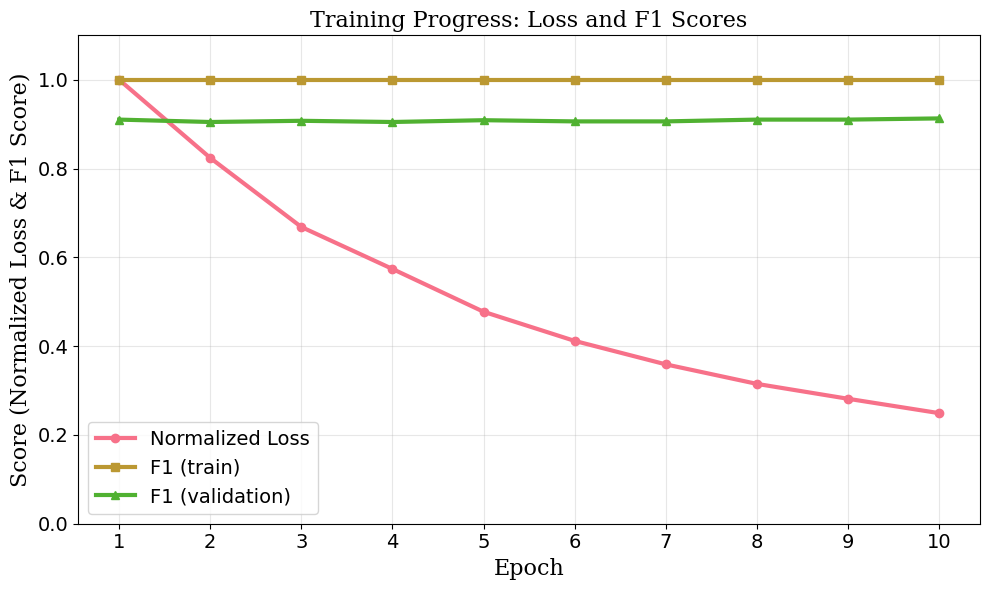


Final Results after 10 epochs:
Training F1 Score: 1.000
Validation F1 Score: 0.913
Final Normalized Loss: 0.249


In [ ]:
# Create epoch range
x = list(range(1, len(losses)+1))

# Convert losses to numpy array
losses = np.asarray(losses)
# Normalize losses so they match the scale in the plot (we are only interested in the trend of the losses!)
losses = losses/np.max(losses)

# Convert F1 scores to numpy arrays (in case they're lists)
f1_train = np.asarray(f1_train)
f1_test = np.asarray(f1_test)

plt.figure(figsize=(10, 6))

# Plot all metrics
plt.plot(x, losses, lw=3, marker='o', markersize=6)
plt.plot(x, f1_train, lw=3, marker='s', markersize=6)
plt.plot(x, f1_test, lw=3, marker='^', markersize=6)

# Font settings
font_axes = {'family':'serif','color':'black','size':16}

# Set x-axis ticks to show all epochs
plt.gca().set_xticks(x)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Labels and legend
plt.xlabel("Epoch", fontdict=font_axes)
plt.ylabel("Score (Normalized Loss & F1 Score)", fontdict=font_axes)
plt.legend(['Normalized Loss', 'F1 (train)', 'F1 (validation)'], loc='best', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Set y-axis limits for better visualization
plt.ylim(0, 1.1)

# Title
plt.title("Training Progress: Loss and F1 Scores", fontdict=font_axes)

plt.tight_layout()
plt.show()

# Print final results
print(f"\nFinal Results after {len(losses)} epochs:")
print(f"Training F1 Score: {f1_train[-1]:.3f}")
print(f"Validation F1 Score: {f1_test[-1]:.3f}")
print(f"Final Normalized Loss: {losses[-1]:.3f}")

In [ ]:
# Print detailed model summary
print("="*80)
print("MODEL ARCHITECTURE SUMMARY")
print("="*80)

print(f"Model: {classifier.__class__.__name__}")
print(f"Total Parameters: {sum(p.numel() for p in classifier.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in classifier.parameters() if p.requires_grad):,}")
print()

# Print each layer with details
print("LAYER-BY-LAYER BREAKDOWN:")
print("-" * 50)

for i, (name, layer) in enumerate(classifier.named_modules()):
    if len(list(layer.children())) == 0:  # Only leaf modules
        # Count parameters for this layer
        params = sum(p.numel() for p in layer.parameters())
        trainable = sum(p.numel() for p in layer.parameters() if p.requires_grad)

        print(f"Layer {i}: {name}")
        print(f"  Type: {layer.__class__.__name__}")
        if hasattr(layer, 'weight') and layer.weight is not None:
            print(f"  Weight shape: {layer.weight.shape}")
        if hasattr(layer, 'bias') and layer.bias is not None:
            print(f"  Bias shape: {layer.bias.shape}")
        print(f"  Parameters: {params:,} (Trainable: {trainable:,})")

        # Special info for specific layer types
        if isinstance(layer, nn.Embedding):
            print(f"  Vocabulary size: {layer.num_embeddings}")
            print(f"  Embedding dimension: {layer.embedding_dim}")
        elif isinstance(layer, nn.Linear):
            print(f"  Input features: {layer.in_features}")
            print(f"  Output features: {layer.out_features}")

        print()

MODEL ARCHITECTURE SUMMARY
Model: TextCNN
Total Parameters: 1,995,202
Trainable Parameters: 120,902

LAYER-BY-LAYER BREAKDOWN:
--------------------------------------------------
Layer 1: embedding
  Type: Embedding
  Weight shape: torch.Size([18743, 100])
  Parameters: 1,874,300 (Trainable: 0)
  Vocabulary size: 18743
  Embedding dimension: 100

Layer 3: convs.0
  Type: Conv1d
  Weight shape: torch.Size([100, 100, 3])
  Bias shape: torch.Size([100])
  Parameters: 30,100 (Trainable: 30,100)

Layer 4: convs.1
  Type: Conv1d
  Weight shape: torch.Size([100, 100, 4])
  Bias shape: torch.Size([100])
  Parameters: 40,100 (Trainable: 40,100)

Layer 5: convs.2
  Type: Conv1d
  Weight shape: torch.Size([100, 100, 5])
  Bias shape: torch.Size([100])
  Parameters: 50,100 (Trainable: 50,100)

Layer 6: fc
  Type: Linear
  Weight shape: torch.Size([2, 300])
  Bias shape: torch.Size([2])
  Parameters: 602 (Trainable: 602)
  Input features: 300
  Output features: 2

Layer 7: log_softmax
  Type: LogSof

In [ ]:
class TextRNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout_rate):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(emb_matrix))
        self.embedding.weight.requires_grad = False
        self.rnn = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout_rate,
                           batch_first=True)
        # Input Layer
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)

        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate)

        # Output layer
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, X):
        embedded = self.embedding(X)
        output, (hidden, cell) = self.rnn(embedded)
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        # Apply dropout
        hidden = self.dropout(hidden)

        # Pass through fully connected layer
        fc_out = self.fc(hidden)

        # Apply LogSoftmax
        log_probs = self.log_softmax(fc_out)

        return log_probs

In [ ]:
import torch
import torch.nn as nn

class TextRNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        output_dim: int,
        n_layers: int,
        bidirectional: bool,
        dropout_rate: float,
        emb_matrix: np.ndarray,    # your pretrained‐embeddings matrix
    ):
        super().__init__()

        # Embedding layer (frozen)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(emb_matrix))
        self.embedding.weight.requires_grad = True

        # Vanilla RNN layer (instead of LSTM)
        self.rnn = nn.RNN(
            input_size   = embedding_dim,
            hidden_size  = hidden_dim,
            num_layers   = n_layers,
            nonlinearity = 'tanh',
            bidirectional= bidirectional,
            dropout      = dropout_rate if n_layers > 1 else 0.0,
            batch_first  = True
        )

        # Compute the input dim for the final FC
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc        = nn.Linear(fc_input_dim, output_dim)
        self.dropout   = nn.Dropout(dropout_rate)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, X):
        embedded = self.embedding(X)
        output, hidden = self.rnn(embedded)

        if self.rnn.bidirectional:
            h_fwd = hidden[-2,:,:]
            h_bwd = hidden[-1,:,:]
            h    = torch.cat((h_fwd, h_bwd), dim=1)
        else:
            h = hidden[-1,:,:]

        h = self.dropout(h)
        logits = self.fc(h)
        return self.log_softmax(logits)


In [ ]:
# Define RNN parameters
hidden_dim = 64
output_dim = 2
n_layers = 1
bidirectional = True
dropout_rate = 0.5

# Create the TextRNN model

rnn_model = TextRNN(vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout_rate, emb_matrix).to(device)

print("TextRNN model created and moved to device:")
print(rnn_model)
print(f"\nHidden dimension: {hidden_dim}")
print(f"Number of layers: {n_layers}")
print(f"Bidirectional: {bidirectional}")
print(f"Dropout rate: {dropout_rate}")

TextRNN model created and moved to device:
TextRNN(
  (embedding): Embedding(18743, 100)
  (rnn): RNN(100, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (log_softmax): LogSoftmax(dim=1)
)

Hidden dimension: 64
Number of layers: 1
Bidirectional: True
Dropout rate: 0.5


In [ ]:
# Define loss function and optimizer
# Reusing the loss function and optimizer from the CNN example
rnn_criterion = nn.NLLLoss() # Negative Log Likelihood Loss
rnn_optimizer = rnn_optimizer = torch.optim.Adam(
    rnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)


print("\nLoss function and Optimizer defined for TextRNN:")
print(f"Loss function: Negative Log Likelihood Loss")
print(f"Optimizer: Adam with learning rate 0.001")


Loss function and Optimizer defined for TextRNN:
Loss function: Negative Log Likelihood Loss
Optimizer: Adam with learning rate 0.001


In [ ]:
# Set the number of epochs (reusing from the CNN example)
num_epochs_rnn = 20

# Train the TextRNN model
print(f"\nStarting training for TextRNN model for {num_epochs_rnn} epochs...")

rnn_losses, rnn_f1_train, rnn_f1_test = train(
    rnn_model,        # The TextRNN model
    train_loader,     # Training data loader
    x_val_loader,     # Validation data loader
    rnn_optimizer,    # Optimizer for the RNN model
    rnn_criterion,    # Loss function for the RNN model
    num_epochs_rnn    # Number of epochs
)

print("\nTextRNN model training completed!")


Starting training for TextRNN model for 20 epochs...


100%|██████████| 12/12 [00:00<00:00, 570.88it/s]


Loss:	8.864, f1 train: 0.990, f1 test: 0.889 (epoch 1)


100%|██████████| 12/12 [00:00<00:00, 799.27it/s]


Loss:	5.154, f1 train: 0.982, f1 test: 0.867 (epoch 2)


...

Loss:	0.270, f1 train: 0.999, f1 test: 0.890 (epoch 18)


100%|██████████| 12/12 [00:00<00:00, 705.28it/s]


Loss:	0.239, f1 train: 0.999, f1 test: 0.889 (epoch 19)


100%|██████████| 12/12 [00:00<00:00, 856.30it/s]

Loss:	0.175, f1 train: 0.999, f1 test: 0.893 (epoch 20)

TextRNN model training completed!


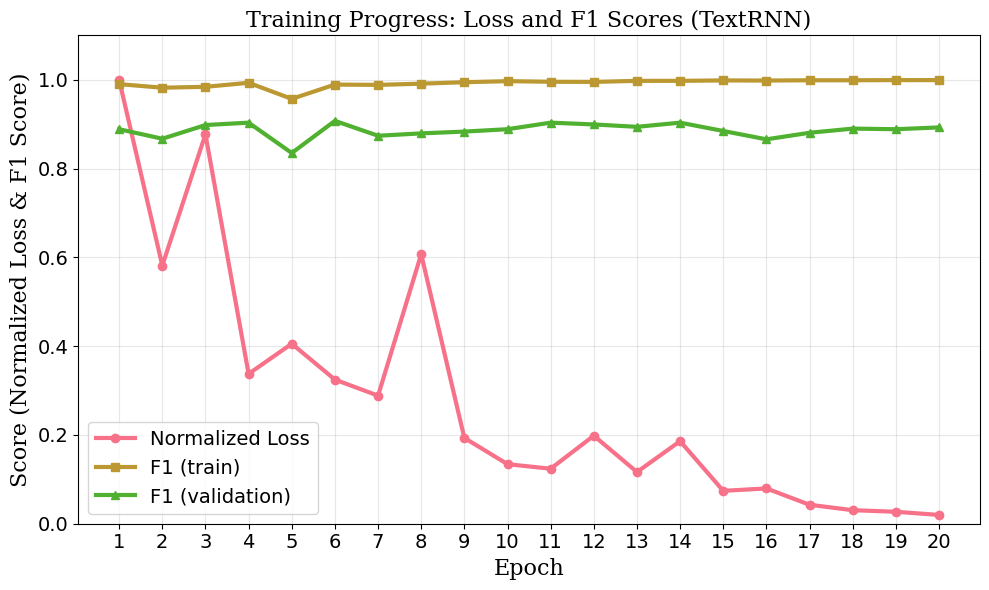


Final Results after 20 epochs:
Training F1 Score: 0.999
Validation F1 Score: 0.893
Final Normalized Loss: 0.020


In [ ]:
# Create epoch range
x = list(range(1, len(rnn_losses)+1))

# Convert losses to numpy array
losses = np.asarray(rnn_losses) # Use rnn_losses
# Normalize losses so they match the scale in the plot (we are only interested in the trend of the losses!)
losses = losses/np.max(losses)

# Convert F1 scores to numpy arrays (in case they're lists)
f1_train = np.asarray(rnn_f1_train) # Use rnn_f1_train
f1_test = np.asarray(rnn_f1_test) # Use rnn_f1_test

plt.figure(figsize=(10, 6))

# Plot all metrics
plt.plot(x, losses, lw=3, marker='o', markersize=6)
plt.plot(x, f1_train, lw=3, marker='s', markersize=6)
plt.plot(x, f1_test, lw=3, marker='^', markersize=6)

# Font settings
font_axes = {'family':'serif','color':'black','size':16}

# Set x-axis ticks to show all epochs
plt.gca().set_xticks(x)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Labels and legend
plt.xlabel("Epoch", fontdict=font_axes)
plt.ylabel("Score (Normalized Loss & F1 Score)", fontdict=font_axes)
plt.legend(['Normalized Loss', 'F1 (train)', 'F1 (validation)'], loc='best', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Set y-axis limits for better visualization
plt.ylim(0, 1.1)

# Title
plt.title("Training Progress: Loss and F1 Scores (TextRNN)", fontdict=font_axes) # Updated title

plt.tight_layout()
plt.show()

# Print final results
print(f"\nFinal Results after {len(losses)} epochs:")
print(f"Training F1 Score: {f1_train[-1]:.3f}")
print(f"Validation F1 Score: {f1_test[-1]:.3f}")
print(f"Final Normalized Loss: {losses[-1]:.3f}")

In [ ]:
# Print detailed model summary
print("="*80)
print("MODEL ARCHITECTURE SUMMARY (TextRNN)") # Updated title
print("="*80)

print(f"Model: {rnn_model.__class__.__name__}") # Changed from classifier to rnn_model
print(f"Total Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}") # Changed from classifier to rnn_model
print(f"Trainable Parameters: {sum(p.numel() for p in rnn_model.parameters() if p.requires_grad):,}") # Changed from classifier to rnn_model
print()

# Print each layer with details
print("LAYER-BY-LAYER BREAKDOWN:")
print("-" * 50)

for i, (name, layer) in enumerate(rnn_model.named_modules()): # Changed from classifier to rnn_model
    # Only process leaf modules and the LSTM layer itself
    if len(list(layer.children())) == 0 or isinstance(layer, nn.LSTM):
        # Count parameters for this layer
        params = sum(p.numel() for p in layer.parameters())
        trainable = sum(p.numel() for p in layer.parameters() if p.requires_grad)

        print(f"Layer {i}: {name}")
        print(f"  Type: {layer.__class__.__name__}")

        # Handle specific layer types
        if isinstance(layer, nn.Embedding):
            if hasattr(layer, 'weight') and layer.weight is not None:
                 print(f"  Weight shape: {layer.weight.shape}")
            print(f"  Vocabulary size: {layer.num_embeddings}")
            print(f"  Embedding dimension: {layer.embedding_dim}")
        elif isinstance(layer, nn.Linear):
            if hasattr(layer, 'weight') and layer.weight is not None:
                print(f"  Weight shape: {layer.weight.shape}")
            if hasattr(layer, 'bias') and layer.bias is not None:
                # Check if bias is a tensor with shape
                if isinstance(layer.bias, torch.Tensor) and layer.bias.dim() > 0:
                    print(f"  Bias shape: {layer.bias.shape}")
                else:
                    print(f"  Bias: {layer.bias}") # Print bias value if not a tensor with shape
            print(f"  Input features: {layer.in_features}")
            print(f"  Output features: {layer.out_features}")
        elif isinstance(layer, nn.RNN): # Specific details for LSTM
             print(f"  Input size: {layer.input_size}")
             print(f"  Hidden size: {layer.hidden_size}")
             print(f"  Number of layers: {layer.num_layers}")
             print(f"  Bidirectional: {layer.bidirectional}")
             # Note: LSTM biases and weights are typically accessed differently
             # For a simple summary, we list main parameters.

        # Print general parameter info for the layer
        print(f"  Parameters: {params:,} (Trainable: {trainable:,})")

        print()

MODEL ARCHITECTURE SUMMARY (TextRNN)
Model: TextRNN
Total Parameters: 1,895,806
Trainable Parameters: 1,895,806

LAYER-BY-LAYER BREAKDOWN:
--------------------------------------------------
Layer 1: embedding
  Type: Embedding
  Weight shape: torch.Size([18743, 100])
  Vocabulary size: 18743
  Embedding dimension: 100
  Parameters: 1,874,300 (Trainable: 1,874,300)

Layer 2: rnn
  Type: RNN
  Input size: 100
  Hidden size: 64
  Number of layers: 1
  Bidirectional: True
  Parameters: 21,248 (Trainable: 21,248)

Layer 3: fc
  Type: Linear
  Weight shape: torch.Size([2, 128])
  Bias shape: torch.Size([2])
  Input features: 128
  Output features: 2
  Parameters: 258 (Trainable: 258)

Layer 4: dropout
  Type: Dropout
  Parameters: 0 (Trainable: 0)

Layer 5: log_softmax
  Type: LogSoftmax
  Parameters: 0 (Trainable: 0)



In [ ]:
class TextLSTM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout_rate):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(emb_matrix))
        self.embedding.weight.requires_grad = False

        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout_rate,
                            batch_first=True)
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)

        # Dropout layer (applied before the final linear layer)
        self.dropout = nn.Dropout(dropout_rate)

        # Output layer (LogSoftmax for NLLLoss)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, X):
        embedded = self.embedding(X)
        output, (hidden, cell) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]


        # Apply dropout
        hidden = self.dropout(hidden)

        # Pass through fully connected layer
        fc_out = self.fc(hidden)

        # Apply LogSoftmax
        log_probs = self.log_softmax(fc_out)

        return log_probs

In [ ]:
# Define LSTM parameters
lstm_hidden_dim = 128
lstm_output_dim = 2 # Binary classification
lstm_n_layers = 2
lstm_bidirectional = True
lstm_dropout_rate = 0.5

# Create the TextLSTM model
lstm_model = TextLSTM(vocab_size, embedding_dim, lstm_hidden_dim, lstm_output_dim, lstm_n_layers, lstm_bidirectional, lstm_dropout_rate).to(device)

print("TextLSTM model created and moved to device:")
print(lstm_model)
print(f"\nHidden dimension: {lstm_hidden_dim}")
print(f"Number of layers: {lstm_n_layers}")
print(f"Bidirectional: {lstm_bidirectional}")
print(f"Dropout rate: {lstm_dropout_rate}")

TextLSTM model created and moved to device:
TextLSTM(
  (embedding): Embedding(18743, 100)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (log_softmax): LogSoftmax(dim=1)
)

Hidden dimension: 128
Number of layers: 2
Bidirectional: True
Dropout rate: 0.5


In [ ]:
# Define loss function and optimizer for TextLSTM
lstm_criterion = nn.NLLLoss() # Negative Log Likelihood Loss
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001) # Adam optimizer

print("\nLoss function and Optimizer defined for TextLSTM:")
print(f"Loss function: Negative Log Likelihood Loss")
print(f"Optimizer: Adam with learning rate 0.001")


Loss function and Optimizer defined for TextLSTM:
Loss function: Negative Log Likelihood Loss
Optimizer: Adam with learning rate 0.001


In [ ]:
# Set the number of epochs
num_epochs_lstm = 20

# Train the TextLSTM model
print(f"\nStarting training for TextLSTM model for {num_epochs_lstm} epochs...")

lstm_losses, lstm_f1_train, lstm_f1_test = train(
    lstm_model,        # The TextLSTM model
    train_loader,     # Training data loader
    x_val_loader,     # Validation data loader
    lstm_optimizer,    # Optimizer for the LSTM model
    lstm_criterion,    # Loss function for the LSTM model
    num_epochs_lstm    # Number of epochs
)

print("\nTextLSTM model training completed!")


Starting training for TextLSTM model for 20 epochs...


100%|██████████| 12/12 [00:00<00:00, 203.20it/s]


Loss:	0.207, f1 train: 0.999, f1 test: 0.902 (epoch 1)


100%|██████████| 12/12 [00:00<00:00, 199.82it/s]


Loss:	1.241, f1 train: 0.991, f1 test: 0.883 (epoch 2)


...

Loss:	0.002, f1 train: 1.000, f1 test: 0.905 (epoch 18)


100%|██████████| 12/12 [00:00<00:00, 210.32it/s]


Loss:	0.042, f1 train: 0.999, f1 test: 0.891 (epoch 19)


100%|██████████| 12/12 [00:00<00:00, 214.09it/s]

Loss:	0.163, f1 train: 1.000, f1 test: 0.916 (epoch 20)

TextLSTM model training completed!


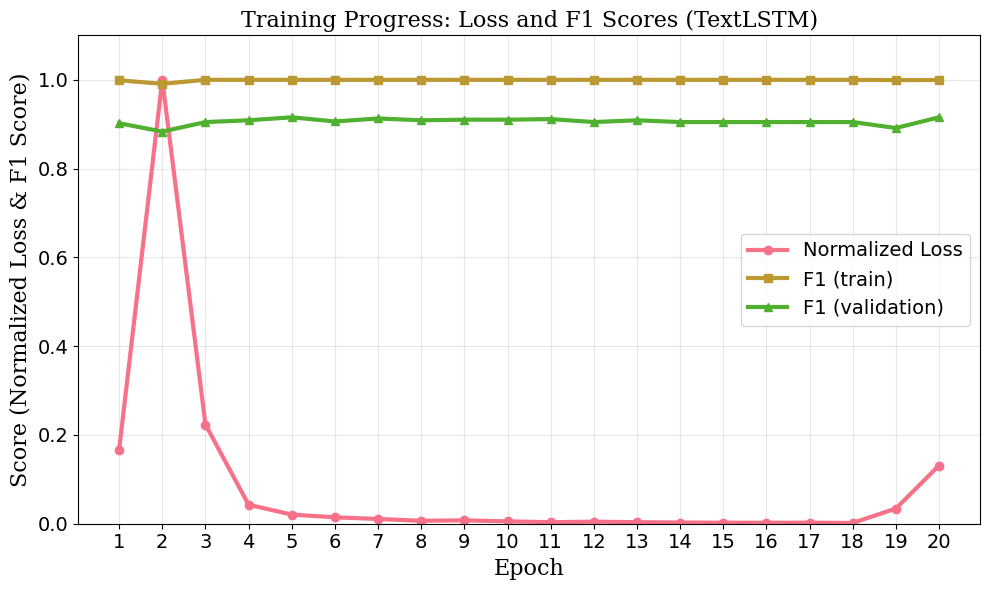


Final Results after 20 epochs:
Training F1 Score: 1.000
Validation F1 Score: 0.916
Final Normalized Loss: 0.131


In [ ]:
# Create epoch range
x = list(range(1, len(lstm_losses)+1))

# Convert losses to numpy array
losses = np.asarray(lstm_losses) # Use lstm_losses
# Normalize losses so they match the scale in the plot (we are only interested in the trend of the losses!)
losses = losses/np.max(losses)

# Convert F1 scores to numpy arrays (in case they're lists)
f1_train = np.asarray(lstm_f1_train) # Use lstm_f1_train
f1_test = np.asarray(lstm_f1_test) # Use lstm_f1_test

plt.figure(figsize=(10, 6))

# Plot all metrics
plt.plot(x, losses, lw=3, marker='o', markersize=6)
plt.plot(x, f1_train, lw=3, marker='s', markersize=6)
plt.plot(x, f1_test, lw=3, marker='^', markersize=6)

# Font settings
font_axes = {'family':'serif','color':'black','size':16}

# Set x-axis ticks to show all epochs
plt.gca().set_xticks(x)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Labels and legend
plt.xlabel("Epoch", fontdict=font_axes)
plt.ylabel("Score (Normalized Loss & F1 Score)", fontdict=font_axes)
plt.legend(['Normalized Loss', 'F1 (train)', 'F1 (validation)'], loc='best', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Set y-axis limits for better visualization
plt.ylim(0, 1.1)

# Title
plt.title("Training Progress: Loss and F1 Scores (TextLSTM)", fontdict=font_axes) # Updated title

plt.tight_layout()
plt.show()

# Print final results
print(f"\nFinal Results after {len(losses)} epochs:")
print(f"Training F1 Score: {f1_train[-1]:.3f}")
print(f"Validation F1 Score: {f1_test[-1]:.3f}")
print(f"Final Normalized Loss: {losses[-1]:.3f}")

In [ ]:
# Print detailed model summary
print("="*80)
print("MODEL ARCHITECTURE SUMMARY (TextLSTM)") # Updated title
print("="*80)

print(f"Model: {lstm_model.__class__.__name__}") # Changed from classifier to lstm_model
print(f"Total Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}") # Changed from classifier to lstm_model
print(f"Trainable Parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}") # Changed from classifier to lstm_model
print()

# Print each layer with details
print("LAYER-BY-LAYER BREAKDOWN:")
print("-" * 50)

for i, (name, layer) in enumerate(lstm_model.named_modules()): # Changed from classifier to lstm_model
    # Only process leaf modules and the LSTM layer itself
    if len(list(layer.children())) == 0 or isinstance(layer, nn.LSTM):
        # Count parameters for this layer
        params = sum(p.numel() for p in layer.parameters())
        trainable = sum(p.numel() for p in layer.parameters() if p.requires_grad)

        print(f"Layer {i}: {name}")
        print(f"  Type: {layer.__class__.__name__}")

        # Handle specific layer types
        if isinstance(layer, nn.Embedding):
            if hasattr(layer, 'weight') and layer.weight is not None:
                 print(f"  Weight shape: {layer.weight.shape}")
            print(f"  Vocabulary size: {layer.num_embeddings}")
            print(f"  Embedding dimension: {layer.embedding_dim}")
        elif isinstance(layer, nn.Linear):
            if hasattr(layer, 'weight') and layer.weight is not None:
                print(f"  Weight shape: {layer.weight.shape}")
            if hasattr(layer, 'bias') and layer.bias is not None:
                # Check if bias is a tensor with shape
                if isinstance(layer.bias, torch.Tensor) and layer.bias.dim() > 0:
                    print(f"  Bias shape: {layer.bias.shape}")
                else:
                    print(f"  Bias: {layer.bias}") # Print bias value if not a tensor with shape
            print(f"  Input features: {layer.in_features}")
            print(f"  Output features: {layer.out_features}")
        elif isinstance(layer, nn.LSTM): # Specific details for LSTM
             print(f"  Input size: {layer.input_size}")
             print(f"  Hidden size: {layer.hidden_size}")
             print(f"  Number of layers: {layer.num_layers}")
             print(f"  Bidirectional: {layer.bidirectional}")
             # Note: LSTM biases and weights are typically accessed differently
             # For a simple summary, we list main parameters.

        # Print general parameter info for the layer
        print(f"  Parameters: {params:,} (Trainable: {trainable:,})")

        print()

MODEL ARCHITECTURE SUMMARY (TextLSTM)
Model: TextLSTM
Total Parameters: 2,505,598
Trainable Parameters: 631,298

LAYER-BY-LAYER BREAKDOWN:
--------------------------------------------------
Layer 1: embedding
  Type: Embedding
  Weight shape: torch.Size([18743, 100])
  Vocabulary size: 18743
  Embedding dimension: 100
  Parameters: 1,874,300 (Trainable: 0)

Layer 2: lstm
  Type: LSTM
  Input size: 100
  Hidden size: 128
  Number of layers: 2
  Bidirectional: True
  Parameters: 630,784 (Trainable: 630,784)

Layer 3: fc
  Type: Linear
  Weight shape: torch.Size([2, 256])
  Bias shape: torch.Size([2])
  Input features: 256
  Output features: 2
  Parameters: 514 (Trainable: 514)

Layer 4: dropout
  Type: Dropout
  Parameters: 0 (Trainable: 0)

Layer 5: log_softmax
  Type: LogSoftmax
  Parameters: 0 (Trainable: 0)



In [ ]:
torch.save(classifier.state_dict(), 'text_cnn_model.pkl')
torch.save(rnn_model.state_dict(), 'text_rnn_model.pkl')
torch.save(lstm_model.state_dict(), 'text_lstm_model.pkl')

In [ ]:
import joblib

# Save the tokenizer to a .pkl file
tokenizer_filename = 'tokenizer.pkl'
joblib.dump(tokenizer, tokenizer_filename)

print(f"Tokenizer saved successfully to {tokenizer_filename}")

Tokenizer saved successfully to tokenizer.pkl
